<a href="https://colab.research.google.com/github/J-cuerora/SE-ALES-Y-SISTEMAS/blob/main/Copia_de_Te_damos_la_bienvenida_a_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PUNTO 1.4

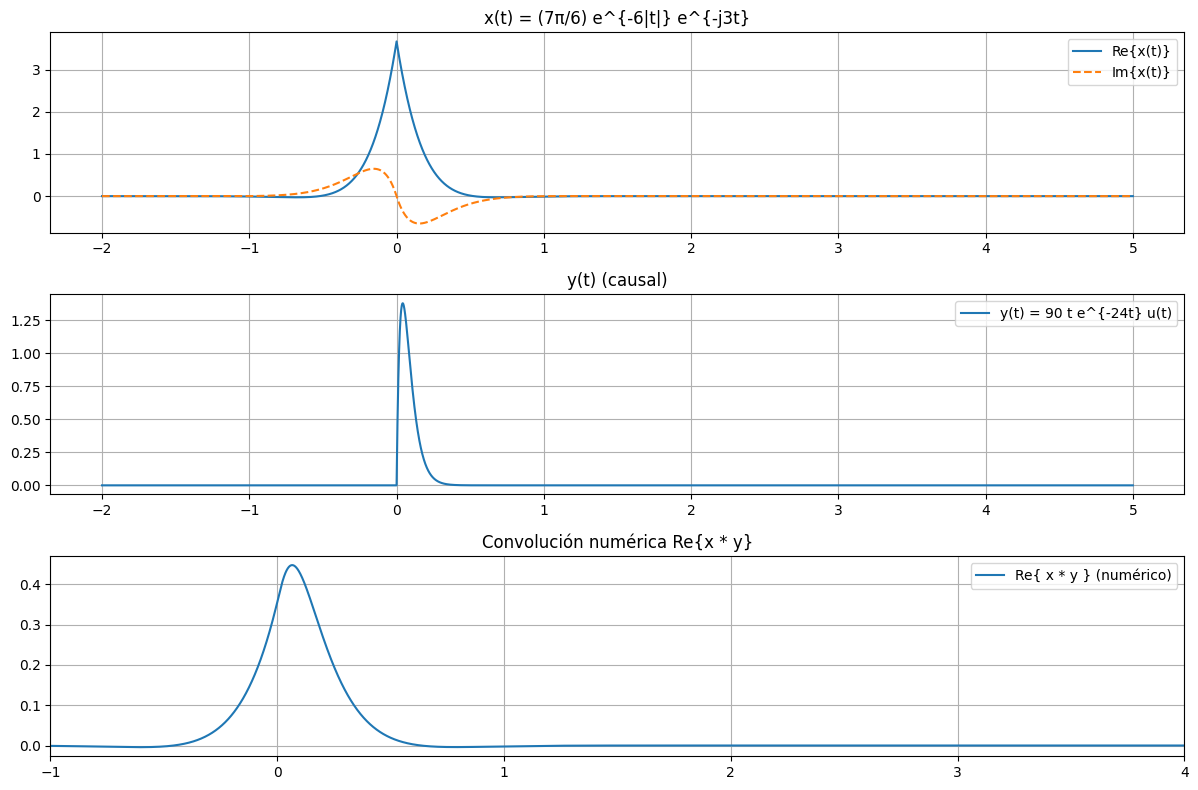

Archivos generados:
  -> senales_xy.csv
  -> convolucion_xy.csv


In [ ]:
# ============================================================
# EJERCICIO 1.4 (c) - Transformada de Fourier y Convolución
# ============================================================
# Calcula numéricamente las señales:
#   x(t) = (7π/6) * e^{-6|t|} * e^{-j3t}
#   y(t) = 90 * t * e^{-24t} * u(t)
# y su convolución h(t) = x(t) * y(t)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Parámetros de simulación ---
dt = 0.001                     # paso temporal
t = np.arange(-2.0, 5.0, dt)   # vector de tiempo

# --- Señal x(t) ---
# x(t) = (7π/6) * e^{-6|t|} * e^{-j3t}
const_x = 7 * np.pi / 6
x = const_x * np.exp(-6 * np.abs(t)) * np.exp(-1j * 3 * t)

# --- Señal y(t) ---
# y(t) = 90 * t * e^{-24t} * u(t)
y = 90 * t * np.exp(-24 * t) * (t >= 0)

# --- Convolución numérica ---
# Se multiplica por dt para compensar el muestreo
conv = np.convolve(x, y, mode='full') * dt
t_conv = np.arange(2 * t[0], 2 * t[-1] + dt, dt)[:len(conv)]

# --- Parte real (ya que x(t) es compleja) ---
conv_real = np.real(conv)

# ============================================================
# GRAFICAR RESULTADOS
# ============================================================

plt.figure(figsize=(12, 8))

# Señal x(t)
plt.subplot(3, 1, 1)
plt.plot(t, np.real(x), label='Re{x(t)}')
plt.plot(t, np.imag(x), linestyle='--', label='Im{x(t)}')
plt.title('x(t) = (7π/6) e^{-6|t|} e^{-j3t}')
plt.legend()
plt.grid(True)

# Señal y(t)
plt.subplot(3, 1, 2)
plt.plot(t, y, label='y(t) = 90 t e^{-24t} u(t)')
plt.title('y(t) (causal)')
plt.legend()
plt.grid(True)

# Convolución x(t)*y(t)
plt.subplot(3, 1, 3)
plt.plot(t_conv, conv_real, label='Re{ x * y } (numérico)')
plt.title('Convolución numérica Re{x * y}')
plt.xlim(-1, 4)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# GUARDAR RESULTADOS EN ARCHIVOS
# ============================================================

# Guardar señales x(t) y y(t)
df_signals = pd.DataFrame({
    't': t,
    'Re_x': np.real(x),
    'Im_x': np.imag(x),
    'y': y
})
df_signals.to_csv('senales_xy.csv', index=False)

# Guardar convolución
df_conv = pd.DataFrame({
    't_conv': t_conv,
    'conv_real': conv_real
})
df_conv.to_csv('convolucion_xy.csv', index=False)

print("Archivos generados:")
print("  -> senales_xy.csv")
print("  -> convolucion_xy.csv")


PUNTO 1.5

# 🧠 Modulación por Amplitud (AM) con Detección Coherente

## 1️⃣ Concepto general

La **modulación por amplitud (AM)** consiste en variar la **amplitud de una portadora sinusoidal** en función de una señal de mensaje o información \( m(t) \).  
De esta manera, la información se “monta” sobre una portadora de frecuencia mucho mayor.

La señal modulada AM se define como:

\[
s(t) = A_c [1 + m(t)] \cos(2\pi f_c t)
\]

donde:

- \( A_c \): amplitud de la portadora  
- \( f_c \): frecuencia de la portadora  
- \( m(t) \): señal de mensaje (normalizada entre -1 y 1)  
- \( m = \frac{A_m}{A_c} \): índice de modulación

El **índice de modulación** indica qué tan profunda es la variación de la amplitud de la portadora.

> Para evitar distorsión:  
> \( 0 \le m \le 1 \)

---

## 2️⃣ Detección coherente

La **detección coherente** es una técnica para recuperar la señal original \( m(t) \) desde la señal modulada.  
Consiste en multiplicar la señal modulada \( s(t) \) por una **réplica sincronizada** de la portadora \( \cos(2\pi f_c t) \) y luego aplicar un **filtro pasa bajos (LPF)**.

\[
r(t) = s(t) \cdot \cos(2\pi f_c t)
\]

Usando la identidad trigonométrica:
\[
\cos^2(2\pi f_c t) = \frac{1 + \cos(4\pi f_c t)}{2}
\]

Obtenemos:
\[
r(t) = \frac{A_c}{2} [1 + m(t)] [1 + \cos(4\pi f_c t)]
\]

Después del filtro pasa bajos (que elimina la componente de alta frecuencia \( 2f_c \)):

\[
r_{filtrado}(t) = \frac{A_c}{2} [1 + m(t)]
\]

De esta forma se recupera la señal de mensaje original.

---

## 3️⃣ Aplicaciones de la modulación AM

- Radiodifusión AM (radio comercial)
- Transmisión de voz y datos en canales analógicos
- Telemetría y radar
- Comunicaciones analógicas punto a punto
- Sistemas de control industrial antiguos

---

## 4️⃣ Tipos de señales mensaje para este ejemplo

En este ejemplo se usarán dos tipos de señales de mensaje:

1. **Pulso rectangular**  
   Representa una señal binaria o de encendido/apagado.

2. **Cosenoidal**  
   Representa una señal analógica continua de baja frecuencia (por ejemplo, audio).

---

## 5️⃣ Objetivo del experimento en Python

- Permitir al usuario **definir el índice de modulación (m)**.  
- Generar y graficar las señales moduladas para:
  - Señal mensaje tipo **pulso rectangular**
  - Señal mensaje tipo **coseno**
- Mostrar tanto las señales en el **dominio del tiempo** como en el **dominio de la frecuencia** (usando `rfft`).

---

## 6️⃣ Fórmulas principales

**Señal modulada:**
\[
s(t) = A_c [1 + m \cdot m(t)] \cos(2\pi f_c t)
\]

**Transformada de Fourier (espectro AM):**
\[
S(f) = \frac{A_c}{2} \left[ \delta(f-f_c) + \delta(f+f_c) \right]
+ \frac{A_c m}{2} [M(f-f_c) + M(f+f_c)]
\]

---

## 7️⃣ Observaciones experimentales esperadas

- Para un **pulso rectangular**, el espectro será **ancho** por su naturaleza discontinua.  
- Para un **coseno**, se observarán **tres componentes principales**: la portadora y las dos bandas laterales.  
- Si el índice de modulación **m > 1**, ocurre **sobre-modulación**, causando distorsión (la envolvente se invierte).  
- En la **detección coherente**, se puede recuperar \( m(t) \) multiplicando por la portadora y filtrando las frecuencias altas.

---

💡 *Conclusión:*  
La modulación AM con detección coherente permite transmitir señales de baja frecuencia sobre una portadora de alta frecuencia, de manera eficiente y con una recuperación precisa cuando existe sincronización entre el transmisor y el receptor.


EJEMPLO PHYTON:

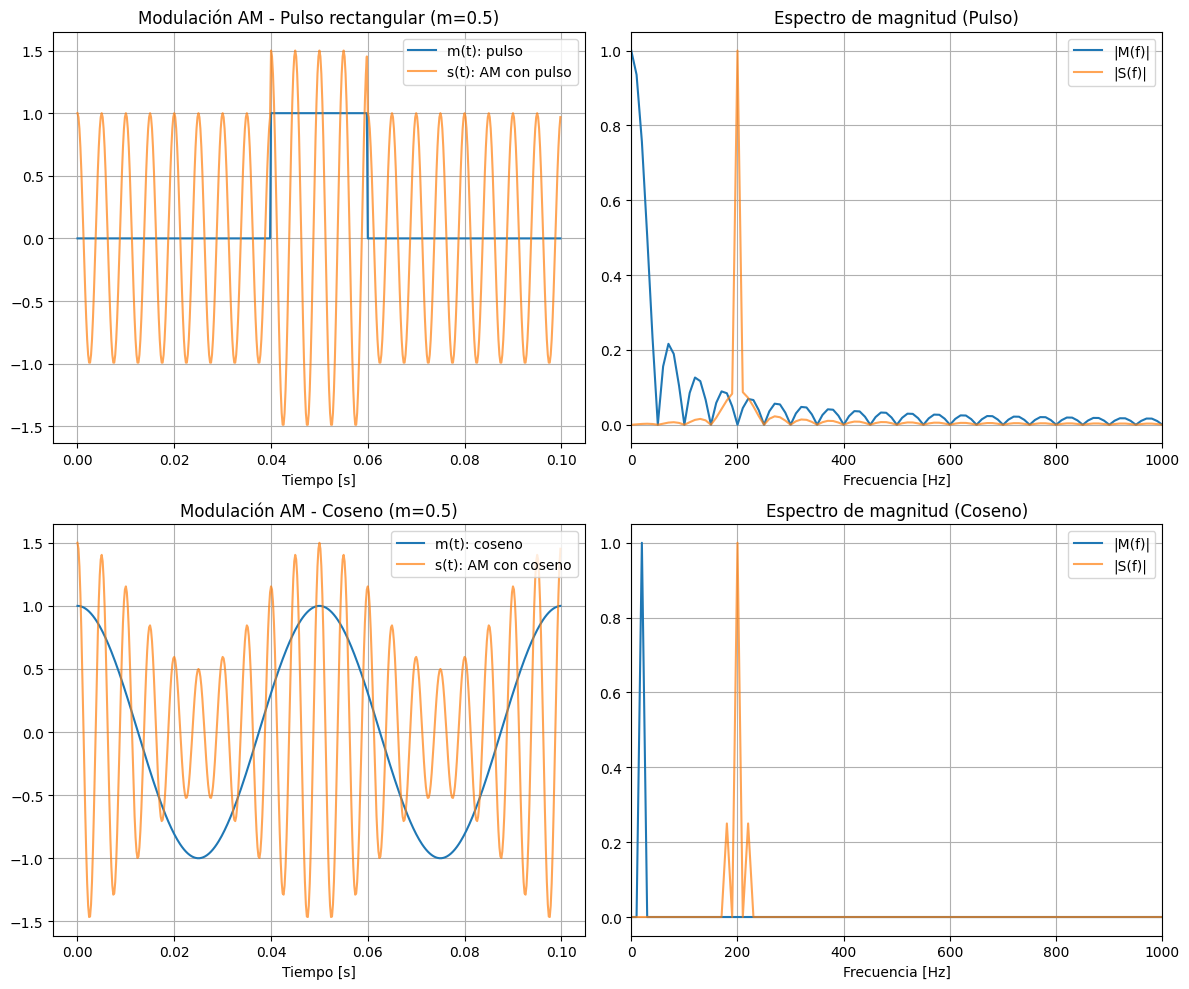

In [ ]:
# ======================================================
# MODULACIÓN AM CON DETECCIÓN COHERENTE
# ======================================================
# - Señal mensaje: pulso rectangular y cosenoidal
# - Índice de modulación m definido por el usuario
# - Gráficos en tiempo y frecuencia (usando rfft)
# ======================================================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parámetros ajustables
# -------------------------------
fs = 5000          # frecuencia de muestreo [Hz]
t_max = 0.1        # duración de la señal [s]
t = np.linspace(0, t_max, int(fs*t_max), endpoint=False)

fc = 200           # frecuencia portadora [Hz]
# m_index = float(input("Ingrese el índice de modulación (0 ≤ m ≤ 1): ") or 0.5) # Removed user input
m_index = 0.5 # Default modulation index

# -------------------------------
# Señal mensaje 1: pulso rectangular
# -------------------------------
# Definimos un pulso de duración 0.02 s centrado en 0.05 s
m_pulso = np.where((t >= 0.04) & (t < 0.06), 1.0, 0.0)

# Señal mensaje 2: coseno
fm = 20   # frecuencia del mensaje [Hz]
m_cos = np.cos(2 * np.pi * fm * t)

# -------------------------------
# Señales moduladas AM
# -------------------------------
Ac = 1.0
s_pulso = Ac * (1 + m_index * m_pulso) * np.cos(2 * np.pi * fc * t)
s_cos = Ac * (1 + m_index * m_cos) * np.cos(2 * np.pi * fc * t)

# -------------------------------
# Transformada rápida (rfft)
# -------------------------------
def rfft_spectrum(signal, fs):
    N = len(signal)
    f = np.fft.rfftfreq(N, 1/fs)
    S = np.abs(np.fft.rfft(signal)) / N
    return f, S

f, M_pulso = rfft_spectrum(m_pulso, fs)
_, M_cos = rfft_spectrum(m_cos, fs)
_, S_pulso = rfft_spectrum(s_pulso, fs)
_, S_cos = rfft_spectrum(s_cos, fs)

# -------------------------------
# GRAFICAR RESULTADOS
# -------------------------------
plt.figure(figsize=(12, 10))

# Señal mensaje y AM (pulso)
plt.subplot(2, 2, 1)
plt.plot(t, m_pulso, label='m(t): pulso')
plt.plot(t, s_pulso, label='s(t): AM con pulso', alpha=0.7)
plt.title(f"Modulación AM - Pulso rectangular (m={m_index})")
plt.xlabel("Tiempo [s]")
plt.legend()
plt.grid(True)

# Espectro (pulso)
plt.subplot(2, 2, 2)
plt.plot(f, M_pulso / np.max(M_pulso), label='|M(f)|')
plt.plot(f, S_pulso / np.max(S_pulso), label='|S(f)|', alpha=0.7)
plt.title("Espectro de magnitud (Pulso)")
plt.xlabel("Frecuencia [Hz]")
plt.xlim(0, 1000)
plt.legend()
plt.grid(True)

# Señal mensaje y AM (coseno)
plt.subplot(2, 2, 3)
plt.plot(t, m_cos, label='m(t): coseno')
plt.plot(t, s_cos, label='s(t): AM con coseno', alpha=0.7)
plt.title(f"Modulación AM - Coseno (m={m_index})")
plt.xlabel("Tiempo [s]")
plt.legend()
plt.grid(True)

# Espectro (coseno)
plt.subplot(2, 2, 4)
plt.plot(f, M_cos / np.max(M_cos), label='|M(f)|')
plt.plot(f, S_cos / np.max(S_cos), label='|S(f)|', alpha=0.7)
plt.title("Espectro de magnitud (Coseno)")
plt.xlabel("Frecuencia [Hz]")
plt.xlim(0, 1000)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

PUNTO 1.6

# 🎧 Modulación en Amplitud (AM) con Detección Coherente

## 1️⃣ Concepto general

La **modulación en amplitud (AM)** es un proceso mediante el cual la **amplitud de una portadora** sinusoidal se hace variar proporcionalmente a la **amplitud instantánea de una señal de mensaje** \( m(t) \).  
De esta manera, la información contenida en \( m(t) \) se transmite a una frecuencia mucho mayor, adecuada para radiocomunicación.

La señal portadora es:

\[
c(t) = A_c \cos(2\pi f_c t)
\]

La señal modulada en amplitud (AM) se define como:

\[
y(t) = A_c [1 + m \cdot m(t)] \cos(2\pi f_c t)
\]

donde:
- \( A_c \): amplitud de la portadora  
- \( f_c \): frecuencia de la portadora  
- \( m(t) \): señal de mensaje (normalizada)  
- \( m = \frac{A_m}{A_c} \): índice de modulación  

---

## 2️⃣ Índice de modulación

El **índice de modulación** \( m \) indica la profundidad de la modulación:

\[
m = \frac{A_m}{A_c}
\]

- Si \( 0 < m < 1 \): modulación correcta  
- Si \( m = 1 \): modulación al 100 %  
- Si \( m > 1 \): **sobre-modulación**, lo que provoca distorsión de la envolvente y pérdida de información

---

## 3️⃣ Espectro de la señal AM

El espectro en frecuencia de la señal AM es:

\[
S(f) = \frac{A_c}{2}[\delta(f-f_c) + \delta(f+f_c)]
       + \frac{A_c m}{2}[M(f-f_c) + M(f+f_c)]
\]

Donde \( M(f) \) es el espectro de la señal de mensaje \( m(t) \).  
Esto significa que la señal AM contiene:
- Una **portadora** en \( \pm f_c \)  
- Dos **bandas laterales**:
  - **Superior (USB)**: desplazada a \( f_c_


In [ ]:
# =============================================
# Simulación AM con fragmento de YouTube (coherente)
# =============================================

# Instalación de dependencias
!pip install yt-dlp soundfile pydub ffmpeg-python

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from pydub import AudioSegment
from yt_dlp import YoutubeDL
from scipy.signal import resample

# -------- Parámetros básicos --------
url = "https://www.youtube.com/watch?v=WxZ1MUPHFkA&list=RDWxZ1MUPHFkA&start_radio=1"
wav_name = "fragmento_audio.wav"
seg_start = 20.0   # segundos
seg_end   = 25.0   # segundos
fs_target = 44100  # Hz
Ac = 1.0
m_index = 1.0      # índice de modulación
fc = 8000.0        # Hz (frecuencia de portadora)
lpf_cutoff = 3000.0  # Hz (filtro pasa bajas para demodulación)

# ------ Descargar audio del video ------
ydl_opts = {
    "format": "bestaudio/best",
    "outtmpl": "audio_download.%(ext)s",
    "quiet": True,
}
with YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

# Convertir y extraer fragmento
audio_all = AudioSegment.from_file("audio_download.m4a")  # o ext que baje
fragmento = audio_all[int(seg_start*1000):int(seg_end*1000)]
fragmento = fragmento.set_frame_rate(fs_target).set_channels(1)
fragmento.export(wav_name, format="wav")

# ------ Cargar WAV y preparar mensaje ------
audio, fs = sf.read(wav_name)
if audio.ndim > 1:
    audio = np.mean(audio, axis=1)
t = np.arange(len(audio)) / fs
m_t = audio / (np.max(np.abs(audio)) + 1e-12)

# ------ Generar portadora y señal AM -------
carrier = Ac * np.cos(2*np.pi*fc * t)
s_t = Ac * (1 + m_index * m_t) * np.cos(2*np.pi*fc * t)

# ------ Demodulación coherente -------
r_t = s_t * np.cos(2*np.pi*fc * t)

def ideal_lpf_time_from_signal(x, fs, cutoff_hz):
    N = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, 1/fs)
    mask = (np.abs(freqs) <= cutoff_hz).astype(float)
    Xf = X * mask
    x_rec = np.fft.irfft(Xf, n=N)
    return x_rec, freqs, np.abs(X), np.abs(Xf)

m_rec, freqs_r, R_mag, Rf_mag = ideal_lpf_time_from_signal(r_t, fs, lpf_cutoff)
m_rec_scaled = (m_rec * 2.0 / Ac) - 1.0

# ------ Espectros con rfft -------
def rfft_mag(x, fs):
    N = len(x)
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(N, 1/fs)
    return f, np.abs(X) / N

f_m, M_mag = rfft_mag(m_t, fs)
f_s, S_mag = rfft_mag(s_t, fs)
f_r, R_mag_full = rfft_mag(r_t, fs)
f_rec, REC_mag = rfft_mag(m_rec_scaled, fs)

# ------ Gráficas -------
plt.figure(figsize=(14,10))

plt.subplot(3,2,1)
plt.plot(t, m_t); plt.title('Mensaje m(t) – tiempo'); plt.xlabel('t [s]'); plt.grid(True)

plt.subplot(3,2,2)
plt.plot(f_m, M_mag); plt.title('|M(f)| – espectro mensaje'); plt.xlim(0, fs/2); plt.grid(True)

plt.subplot(3,2,3)
plt.plot(t, s_t); plt.title('Señal AM s(t) – tiempo (m=%.1f)'%m_index); plt.xlabel('t [s]'); plt.grid(True)

plt.subplot(3,2,4)
plt.plot(f_s, S_mag); plt.title('|S(f)| – espectro modulada'); plt.xlim(0, fs/2); plt.grid(True)

plt.subplot(3,2,5)
plt.plot(t, r_t, label='r(t)=s·cos'); plt.plot(t, m_rec_scaled, label='m_rec(t) escalada', alpha=0.7)
plt.title('Multiplicación y señal recuperada – tiempo'); plt.xlabel('t [s]'); plt.legend(); plt.grid(True)

plt.subplot(3,2,6)
plt.plot(f_r, R_mag_full, label='|R(f)| antes LPF')
plt.plot(f_rec, REC_mag, label='|M_rec(f)| después LPF', alpha=0.7)
plt.title('Espectros tras demodulación'); plt.xlim(0, fs/2); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 82.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):
         player = https://www.youtube.com/s/player/5cf6312f/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U


         player = https://www.youtube.com/s/player/5cf6312f/player_ias.vflset/en_US/base.js
         n = Ej3BUkVjEeTRe10 ; player = https://www.youtube.com/s/player/5cf6312f/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U


         player = https://www.youtube.com/s/player/5cf6312f/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U


         player = https://www.youtube.com/s/player/5cf6312f/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U


...

         player = https://www.youtube.com/s/player/5cf6312f/player_ias.vflset/en_US/base.js
         n = _95K6QAMaLOT13B ; player = https://www.youtube.com/s/player/5cf6312f/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U


         player = https://www.youtube.com/s/player/5cf6312f/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U


         player = https://www.youtube.com/s/player/5cf6312f/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U


ERROR: [youtube] V_V7m0xglVg: Sign in to confirm your age. This video may be inappropriate for some users. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies


DownloadError: ERROR: [youtube] V_V7m0xglVg: Sign in to confirm your age. This video may be inappropriate for some users. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies